# WEATHER PREDICTION - COMPLETE PROJECT

### DATA UNDERSTANDING
### Import Libraries

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

### Load Dataset

Note: Naming of the columns is also fixed here.

In [39]:
df = pd.read_csv('open-meteo-cesena2015-2025.csv')
df.head()

,time,temperature_2m (Â°C),relative_humidity_2m (%),precipitation (mm),surface_pressure (hPa),soil_temperature_0_to_7cm (Â°C),wind_speed_10m (km/h),wind_direction_10m (Â°),wind_gusts_10m (km/h),dew_point_2m (Â°C),apparent_temperature (Â°C),cloud_cover (%),pressure_msl (hPa)
0,2015-01-01T00:00,-2.8,77,0.0,1026.5,1.5,8.2,319,16.6,-6.3,-6.9,8,1032.6
1,2015-01-01T06:00,-3.6,75,0.0,1027.9,1.1,13.8,290,30.6,-7.4,-8.6,17,1034.0
2,2015-01-01T12:00,2.1,69,0.0,1028.9,1.7,15.7,323,28.8,-2.9,-2.7,40,1034.9
3,2015-01-01T18:00,1.8,75,0.0,1028.7,2.7,9.7,297,16.6,-2.3,-2.1,58,1034.7
4,2015-01-02T00:00,-2.4,76,0.0,1028.4,1.9,9.7,272,16.6,-6.0,-6.7,4,1034.5


In [40]:
# FIX: Clean column names (replace encoding issues)
df.columns = df.columns.str.replace('Â°', '°')

print(f'Shape: {df.shape}')
for col in df.columns:
    print(f'- {col}')

Shape: (16072, 13)
- time
- temperature_2m (°C)
- relative_humidity_2m (%)
- precipitation (mm)
- surface_pressure (hPa)
- soil_temperature_0_to_7cm (°C)
- wind_speed_10m (km/h)
- wind_direction_10m (°)
- wind_gusts_10m (km/h)
- dew_point_2m (°C)
- apparent_temperature (°C)
- cloud_cover (%)
- pressure_msl (hPa)


### Data Info

In [41]:
print('Dataset Information:')
df.info()
print('\nMissing Values:')
print(df.isnull().sum())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 16072 entries, 0 to 16071
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   time                            16072 non-null  str    
 1   temperature_2m (°C)             16072 non-null  float64
 2   relative_humidity_2m (%)        16072 non-null  int64  
 3   precipitation (mm)              16072 non-null  float64
 4   surface_pressure (hPa)          16072 non-null  float64
 5   soil_temperature_0_to_7cm (°C)  16072 non-null  float64
 6   wind_speed_10m (km/h)           16072 non-null  float64
 7   wind_direction_10m (°)          16072 non-null  int64  
 8   wind_gusts_10m (km/h)           16072 non-null  float64
 9   dew_point_2m (°C)               16072 non-null  float64
 10  apparent_temperature (°C)       16072 non-null  float64
 11  cloud_cover (%)                 16072 non-null  int64  
 12  pressure_msl (hPa)    

There is no missing data, therefore there is no need for imputation. However, all data types are numeric except time. It must be converted to date time.

Note: In Colab, 'time' data type is shown as str. In pandas, object and string type are very similar but not the same. Object type uses pointers to store the string variables. Different versions of pandas library can cause different results in colab and jupyter. This difference is not very important in this project.

### Statistical Summary

In [42]:
df.describe()

,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),surface_pressure (hPa),soil_temperature_0_to_7cm (°C),wind_speed_10m (km/h),wind_direction_10m (°),wind_gusts_10m (km/h),dew_point_2m (°C),apparent_temperature (°C),cloud_cover (%),pressure_msl (hPa)
count,16072.000000,16072.000000,16072.000000,16072.000000,16072.000000,16072.000000,16072.000000,16072.000000,16072.000000,16072.000000,16072.000000,16072.000000
mean,14.732199,74.189584,0.568330,1010.444662,15.532305,8.494823,191.064211,18.685727,9.511797,13.721323,49.727227,1016.098550
std,8.465981,18.689604,1.995211,7.727320,8.381555,4.836949,94.678053,9.991210,6.319684,10.044394,41.216554,7.812537
min,-8.500000,17.000000,0.000000,970.100000,-1.900000,0.000000,1.000000,1.100000,-16.800000,-12.800000,0.000000,975.700000
25%,8.000000,60.000000,0.000000,1006.000000,8.600000,5.300000,103.000000,11.500000,5.000000,5.700000,4.000000,1011.500000
50%,14.200000,77.000000,0.000000,1010.200000,14.900000,7.500000,216.000000,16.600000,9.700000,13.100000,46.000000,1015.800000
75%,21.000000,91.000000,0.000000,1014.900000,21.900000,10.600000,266.000000,23.800000,14.600000,21.500000,97.000000,1020.600000
max,40.800000,100.000000,28.600000,1036.800000,37.400000,47.500000,360.000000,99.700000,24.900000,39.800000,100.000000,1042.800000


---
## Feature Engineering
### Daily Aggregation
**Converting 6-hourly measurements (00:00, 06:00, 12:00, 18:00) to daily data:**
- Temperature: Extract daily MAX and MIN
- Precipitation: SUM (total daily rainfall)
- Wind gusts: MAX (captures extreme events)
- Other variables: MEAN (daily average)

In [43]:
# Convert time to datetime
df['time'] = pd.to_datetime(df['time'])

# Extract date for grouping
df['date'] = df['time'].dt.date

print(f'Original dataset shape: {df.shape}')
print(f'Measurements per day: {len(df) // df["date"].nunique()}')
df.head()

Original dataset shape: (16072, 14)
Measurements per day: 4


,time,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),surface_pressure (hPa),soil_temperature_0_to_7cm (°C),wind_speed_10m (km/h),wind_direction_10m (°),wind_gusts_10m (km/h),dew_point_2m (°C),apparent_temperature (°C),cloud_cover (%),pressure_msl (hPa),date
0,2015-01-01 00:00:00,-2.8,77,0.0,1026.5,1.5,8.2,319,16.6,-6.3,-6.9,8,1032.6,2015-01-01
1,2015-01-01 06:00:00,-3.6,75,0.0,1027.9,1.1,13.8,290,30.6,-7.4,-8.6,17,1034.0,2015-01-01
2,2015-01-01 12:00:00,2.1,69,0.0,1028.9,1.7,15.7,323,28.8,-2.9,-2.7,40,1034.9,2015-01-01
3,2015-01-01 18:00:00,1.8,75,0.0,1028.7,2.7,9.7,297,16.6,-2.3,-2.1,58,1034.7,2015-01-01
4,2015-01-02 00:00:00,-2.4,76,0.0,1028.4,1.9,9.7,272,16.6,-6.0,-6.7,4,1034.5,2015-01-02


In [44]:
# Define aggregation rules for each column
agg_dict = {
    # Temperature: max and min
    'temperature_2m (°C)': ['max', 'min'],
    # Apparent temperature: max and min (feels like temperature)
    'apparent_temperature (°C)': ['max', 'min'],
    # Precipitation: sum (total daily rainfall)
    'precipitation (mm)': 'sum',
    # Wind gusts: max (extreme events)
    'wind_gusts_10m (km/h)': 'max',
    # All other variables: mean (daily average)
    'surface_pressure (hPa)': 'mean',
    'pressure_msl (hPa)': 'mean',
    'wind_speed_10m (km/h)': 'mean',
    'soil_temperature_0_to_7cm (°C)': 'mean',
    'relative_humidity_2m (%)': 'mean',
    'dew_point_2m (°C)': 'mean',
    'wind_direction_10m (°)': 'mean',
    'cloud_cover (%)': 'mean'
}

# Perform daily aggregation
df_daily = df.groupby('date').agg(agg_dict)
df_daily.head()

temperature_2m (°C)      apparent_temperature (°C)       \
                           max  min                       max  min   
date                                                                 
2015-01-01                 2.1 -3.6                      -2.1 -8.6   
2015-01-02                 9.9 -3.3                       7.4 -7.7   
2015-01-03                10.4 -1.7                       8.8 -5.4   
2015-01-04                11.5  5.5                       9.4  2.9   
2015-01-05                 9.9 -1.7                       6.2 -5.4   

           precipitation (mm) wind_gusts_10m (km/h) surface_pressure (hPa)  \
                          sum                   max                   mean   
date                                                                         
2015-01-01                0.0                  30.6               1028.000   
2015-01-02                0.0                  16.6               1026.125   
2015-01-03                0.0                  11.2               1019.800   
2015-01-04                0.0                  16.9               1014.125   
2015-01-05                0.5                  15.5               1022.275   

           pressure_msl (hPa) wind_speed_10m (km/h)  \
                         mean                  mean   
date                                                  
2015-01-01           1034.050                11.850   
2015-01-02           1032.100                 6.700   
2015-01-03           1025.750                 6.625   
2015-01-04           1019.925                 9.950   
2015-01-05           1028.225                 8.350   

           soil_temperature_0_to_7cm (°C) relative_humidity_2m (%)  \
                                     mean                     mean   
date                                                                 
2015-01-01                          1.750                    74.00   
2015-01-02                          2.675                    74.00   
2015-01-03                          3.850                    86.75   
2015-01-04                          5.275                    87.00   
2015-01-05                          3.400                    68.50   

           dew_point_2m (°C) wind_direction_10m (°) cloud_cover (%)  
                        mean                   mean            mean  
date                                                                 
2015-01-01            -4.725                 307.25           30.75  
2015-01-02            -2.450                 257.50           48.50  
2015-01-03             1.375                 232.75           85.25  
2015-01-04             5.100                 152.75           18.00  
2015-01-05            -2.475                 254.50            0.75

In [45]:
# Flatten multi-level column names
df_daily.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df_daily.columns]

# Rename columns for clarity
df_daily = df_daily.rename(columns={
    'temperature_2m (°C)_max': 'temp_max (°C)',
    'temperature_2m (°C)_min': 'temp_min (°C)',
    'apparent_temperature (°C)_max': 'apparent_temp_max (°C)',
    'apparent_temperature (°C)_min': 'apparent_temp_min (°C)',
    'precipitation (mm)_sum': 'precipitation_total (mm)',
    'wind_gusts_10m (km/h)_max': 'wind_gusts_max (km/h)',
    'surface_pressure (hPa)_mean': 'surface_pressure_avg (hPa)',
    'pressure_msl (hPa)_mean': 'pressure_msl_avg (hPa)',
    'wind_speed_10m (km/h)_mean': 'wind_speed_avg (km/h)',
    'soil_temperature_0_to_7cm (°C)_mean': 'soil_temp_avg (°C)',
    'relative_humidity_2m (%)_mean': 'humidity_avg (%)',
    'dew_point_2m (°C)_mean': 'dew_point_avg (°C)',
    'wind_direction_10m (°)_mean': 'wind_direction_avg (°)',
    'cloud_cover (%)_mean': 'cloud_cover_avg (%)'
})

df_daily.head()

,temp_max (°C),temp_min (°C),apparent_temp_max (°C),apparent_temp_min (°C),precipitation_total (mm),wind_gusts_max (km/h),surface_pressure_avg (hPa),pressure_msl_avg (hPa),wind_speed_avg (km/h),soil_temp_avg (°C),humidity_avg (%),dew_point_avg (°C),wind_direction_avg (°),cloud_cover_avg (%)
date,,,,,,,,,,,,,,
2015-01-01,2.1,-3.6,-2.1,-8.6,0.0,30.6,1028.000,1034.050,11.850,1.750,74.00,-4.725,307.25,30.75
2015-01-02,9.9,-3.3,7.4,-7.7,0.0,16.6,1026.125,1032.100,6.700,2.675,74.00,-2.450,257.50,48.50
2015-01-03,10.4,-1.7,8.8,-5.4,0.0,11.2,1019.800,1025.750,6.625,3.850,86.75,1.375,232.75,85.25
2015-01-04,11.5,5.5,9.4,2.9,0.0,16.9,1014.125,1019.925,9.950,5.275,87.00,5.100,152.75,18.00
2015-01-05,9.9,-1.7,6.2,-5.4,0.5,15.5,1022.275,1028.225,8.350,3.400,68.50,-2.475,254.50,0.75


In [46]:
# Reset index to make date a column
df_daily = df_daily.reset_index()
df_daily.head()

,date,temp_max (°C),temp_min (°C),apparent_temp_max (°C),apparent_temp_min (°C),precipitation_total (mm),wind_gusts_max (km/h),surface_pressure_avg (hPa),pressure_msl_avg (hPa),wind_speed_avg (km/h),soil_temp_avg (°C),humidity_avg (%),dew_point_avg (°C),wind_direction_avg (°),cloud_cover_avg (%)
0,2015-01-01,2.1,-3.6,-2.1,-8.6,0.0,30.6,1028.000,1034.050,11.850,1.750,74.00,-4.725,307.25,30.75
1,2015-01-02,9.9,-3.3,7.4,-7.7,0.0,16.6,1026.125,1032.100,6.700,2.675,74.00,-2.450,257.50,48.50
2,2015-01-03,10.4,-1.7,8.8,-5.4,0.0,11.2,1019.800,1025.750,6.625,3.850,86.75,1.375,232.75,85.25
3,2015-01-04,11.5,5.5,9.4,2.9,0.0,16.9,1014.125,1019.925,9.950,5.275,87.00,5.100,152.75,18.00
4,2015-01-05,9.9,-1.7,6.2,-5.4,0.5,15.5,1022.275,1028.225,8.350,3.400,68.50,-2.475,254.50,0.75


In [47]:
# Convert date back to datetime for further processing
df_daily['date'] = pd.to_datetime(df_daily['date'])

# Replace the original dataframe
df = df_daily.copy()

print(f'\nAggregated dataset shape: {df.shape}')
print(f'\nNew columns:')
for col in df.columns:
    print(f'  - {col}')

df.head()


Aggregated dataset shape: (4018, 15)

New columns:
  - date
  - temp_max (°C)
  - temp_min (°C)
  - apparent_temp_max (°C)
  - apparent_temp_min (°C)
  - precipitation_total (mm)
  - wind_gusts_max (km/h)
  - surface_pressure_avg (hPa)
  - pressure_msl_avg (hPa)
  - wind_speed_avg (km/h)
  - soil_temp_avg (°C)
  - humidity_avg (%)
  - dew_point_avg (°C)
  - wind_direction_avg (°)
  - cloud_cover_avg (%)


,date,temp_max (°C),temp_min (°C),apparent_temp_max (°C),apparent_temp_min (°C),precipitation_total (mm),wind_gusts_max (km/h),surface_pressure_avg (hPa),pressure_msl_avg (hPa),wind_speed_avg (km/h),soil_temp_avg (°C),humidity_avg (%),dew_point_avg (°C),wind_direction_avg (°),cloud_cover_avg (%)
0,2015-01-01,2.1,-3.6,-2.1,-8.6,0.0,30.6,1028.000,1034.050,11.850,1.750,74.00,-4.725,307.25,30.75
1,2015-01-02,9.9,-3.3,7.4,-7.7,0.0,16.6,1026.125,1032.100,6.700,2.675,74.00,-2.450,257.50,48.50
2,2015-01-03,10.4,-1.7,8.8,-5.4,0.0,11.2,1019.800,1025.750,6.625,3.850,86.75,1.375,232.75,85.25
3,2015-01-04,11.5,5.5,9.4,2.9,0.0,16.9,1014.125,1019.925,9.950,5.275,87.00,5.100,152.75,18.00
4,2015-01-05,9.9,-1.7,6.2,-5.4,0.5,15.5,1022.275,1028.225,8.350,3.400,68.50,-2.475,254.50,0.75


### Create Temporal Features
**Extracting year, month, day and creating season column from daily data**

In [48]:
# Extract temporal features from date
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek

# Create season column
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

# this non-numeric column is only added for the plots
df['season'] = df['month'].apply(get_season)

print(f'\nDataset shape: {df.shape}')
df.head()


Dataset shape: (4018, 20)


,date,temp_max (°C),temp_min (°C),apparent_temp_max (°C),apparent_temp_min (°C),precipitation_total (mm),wind_gusts_max (km/h),surface_pressure_avg (hPa),pressure_msl_avg (hPa),wind_speed_avg (km/h),soil_temp_avg (°C),humidity_avg (%),dew_point_avg (°C),wind_direction_avg (°),cloud_cover_avg (%),year,month,day,day_of_week,season
0,2015-01-01,2.1,-3.6,-2.1,-8.6,0.0,30.6,1028.000,1034.050,11.850,1.750,74.00,-4.725,307.25,30.75,2015,1,1,3,Winter
1,2015-01-02,9.9,-3.3,7.4,-7.7,0.0,16.6,1026.125,1032.100,6.700,2.675,74.00,-2.450,257.50,48.50,2015,1,2,4,Winter
2,2015-01-03,10.4,-1.7,8.8,-5.4,0.0,11.2,1019.800,1025.750,6.625,3.850,86.75,1.375,232.75,85.25,2015,1,3,5,Winter
3,2015-01-04,11.5,5.5,9.4,2.9,0.0,16.9,1014.125,1019.925,9.950,5.275,87.00,5.100,152.75,18.00,2015,1,4,6,Winter
4,2015-01-05,9.9,-1.7,6.2,-5.4,0.5,15.5,1022.275,1028.225,8.350,3.400,68.50,-2.475,254.50,0.75,2015,1,5,0,Winter


---
## Exploratory Data Analysis
### Temperature Distribution
**Visualizing temperature distribution with histogram and boxplot by year**

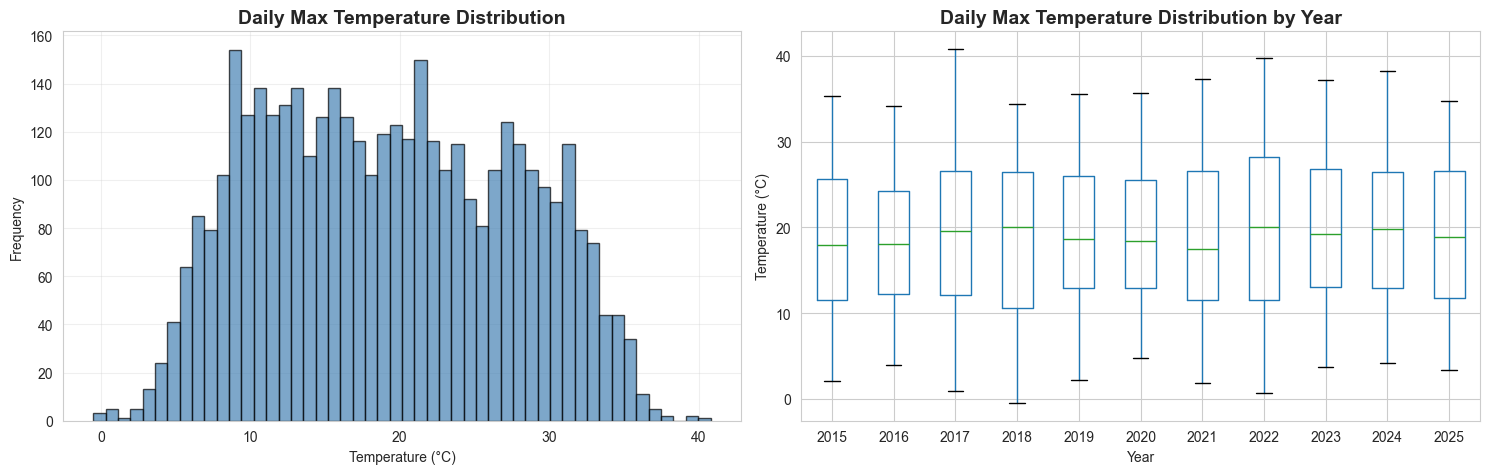

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram - using temp_max for distribution analysis
axes[0].hist(df['temp_max (°C)'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Daily Max Temperature Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Boxplot by year
df.boxplot(column='temp_max (°C)', by='year', ax=axes[1])
axes[1].set_title('Daily Max Temperature Distribution by Year', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Temperature (°C)')
plt.suptitle('')

plt.tight_layout()
plt.show()

In [50]:
print(f"Daily max temperature range: {df['temp_max (°C)'].min():.1f}°C to {df['temp_max (°C)'].max():.1f}°C")
print(f"Mean daily max temperature: {df['temp_max (°C)'].mean():.1f}°C")
print(f"Daily min temperature range: {df['temp_min (°C)'].min():.1f}°C to {df['temp_min (°C)'].max():.1f}°C")
print(f"Mean daily min temperature: {df['temp_min (°C)'].mean():.1f}°C")

Daily max temperature range: -0.5°C to 40.8°C
Mean daily max temperature: 19.2°C
Daily min temperature range: -8.5°C to 26.1°C
Mean daily min temperature: 11.0°C


### Temperature Over Time
**Time series visualization of temperature trends**

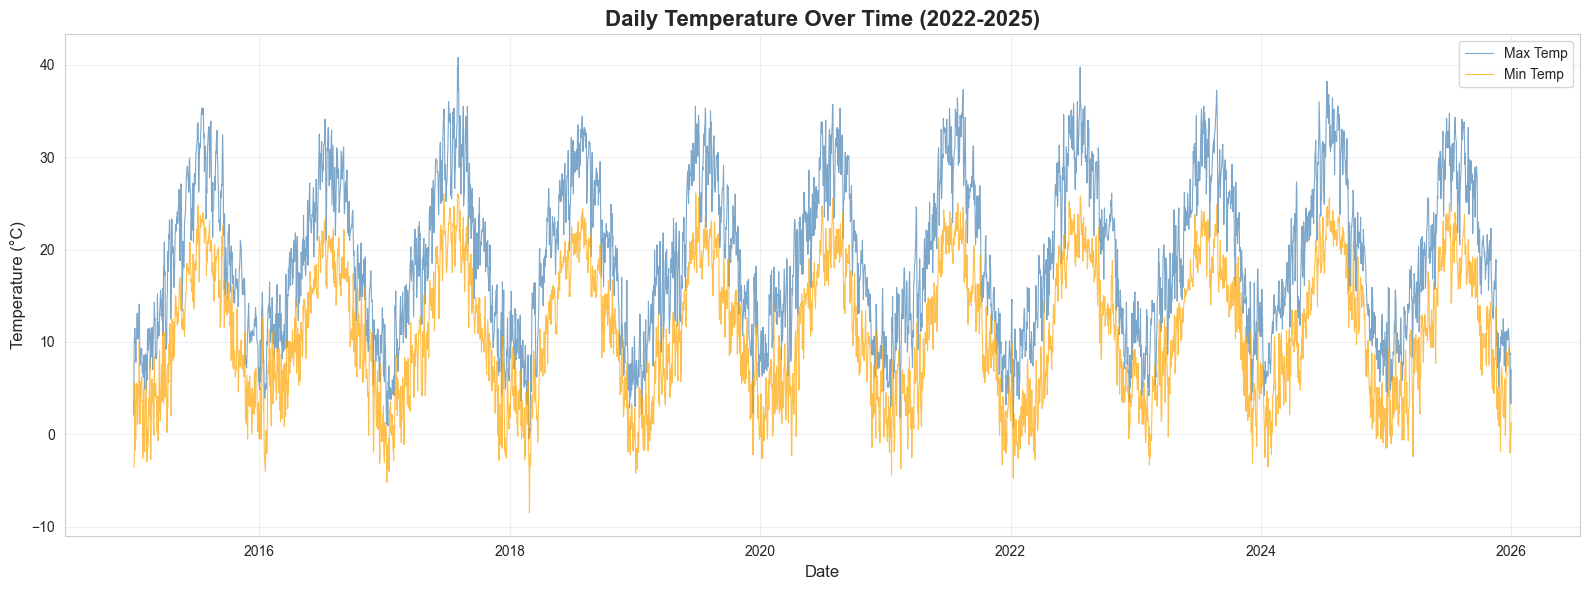

In [51]:
plt.figure(figsize=(16, 6))
plt.plot(df['date'], df['temp_max (°C)'], alpha=0.7, linewidth=0.8, color='steelblue', label='Max Temp')
plt.plot(df['date'], df['temp_min (°C)'], alpha=0.7, linewidth=0.8, color='orange', label='Min Temp')
plt.title('Daily Temperature Over Time (2022-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

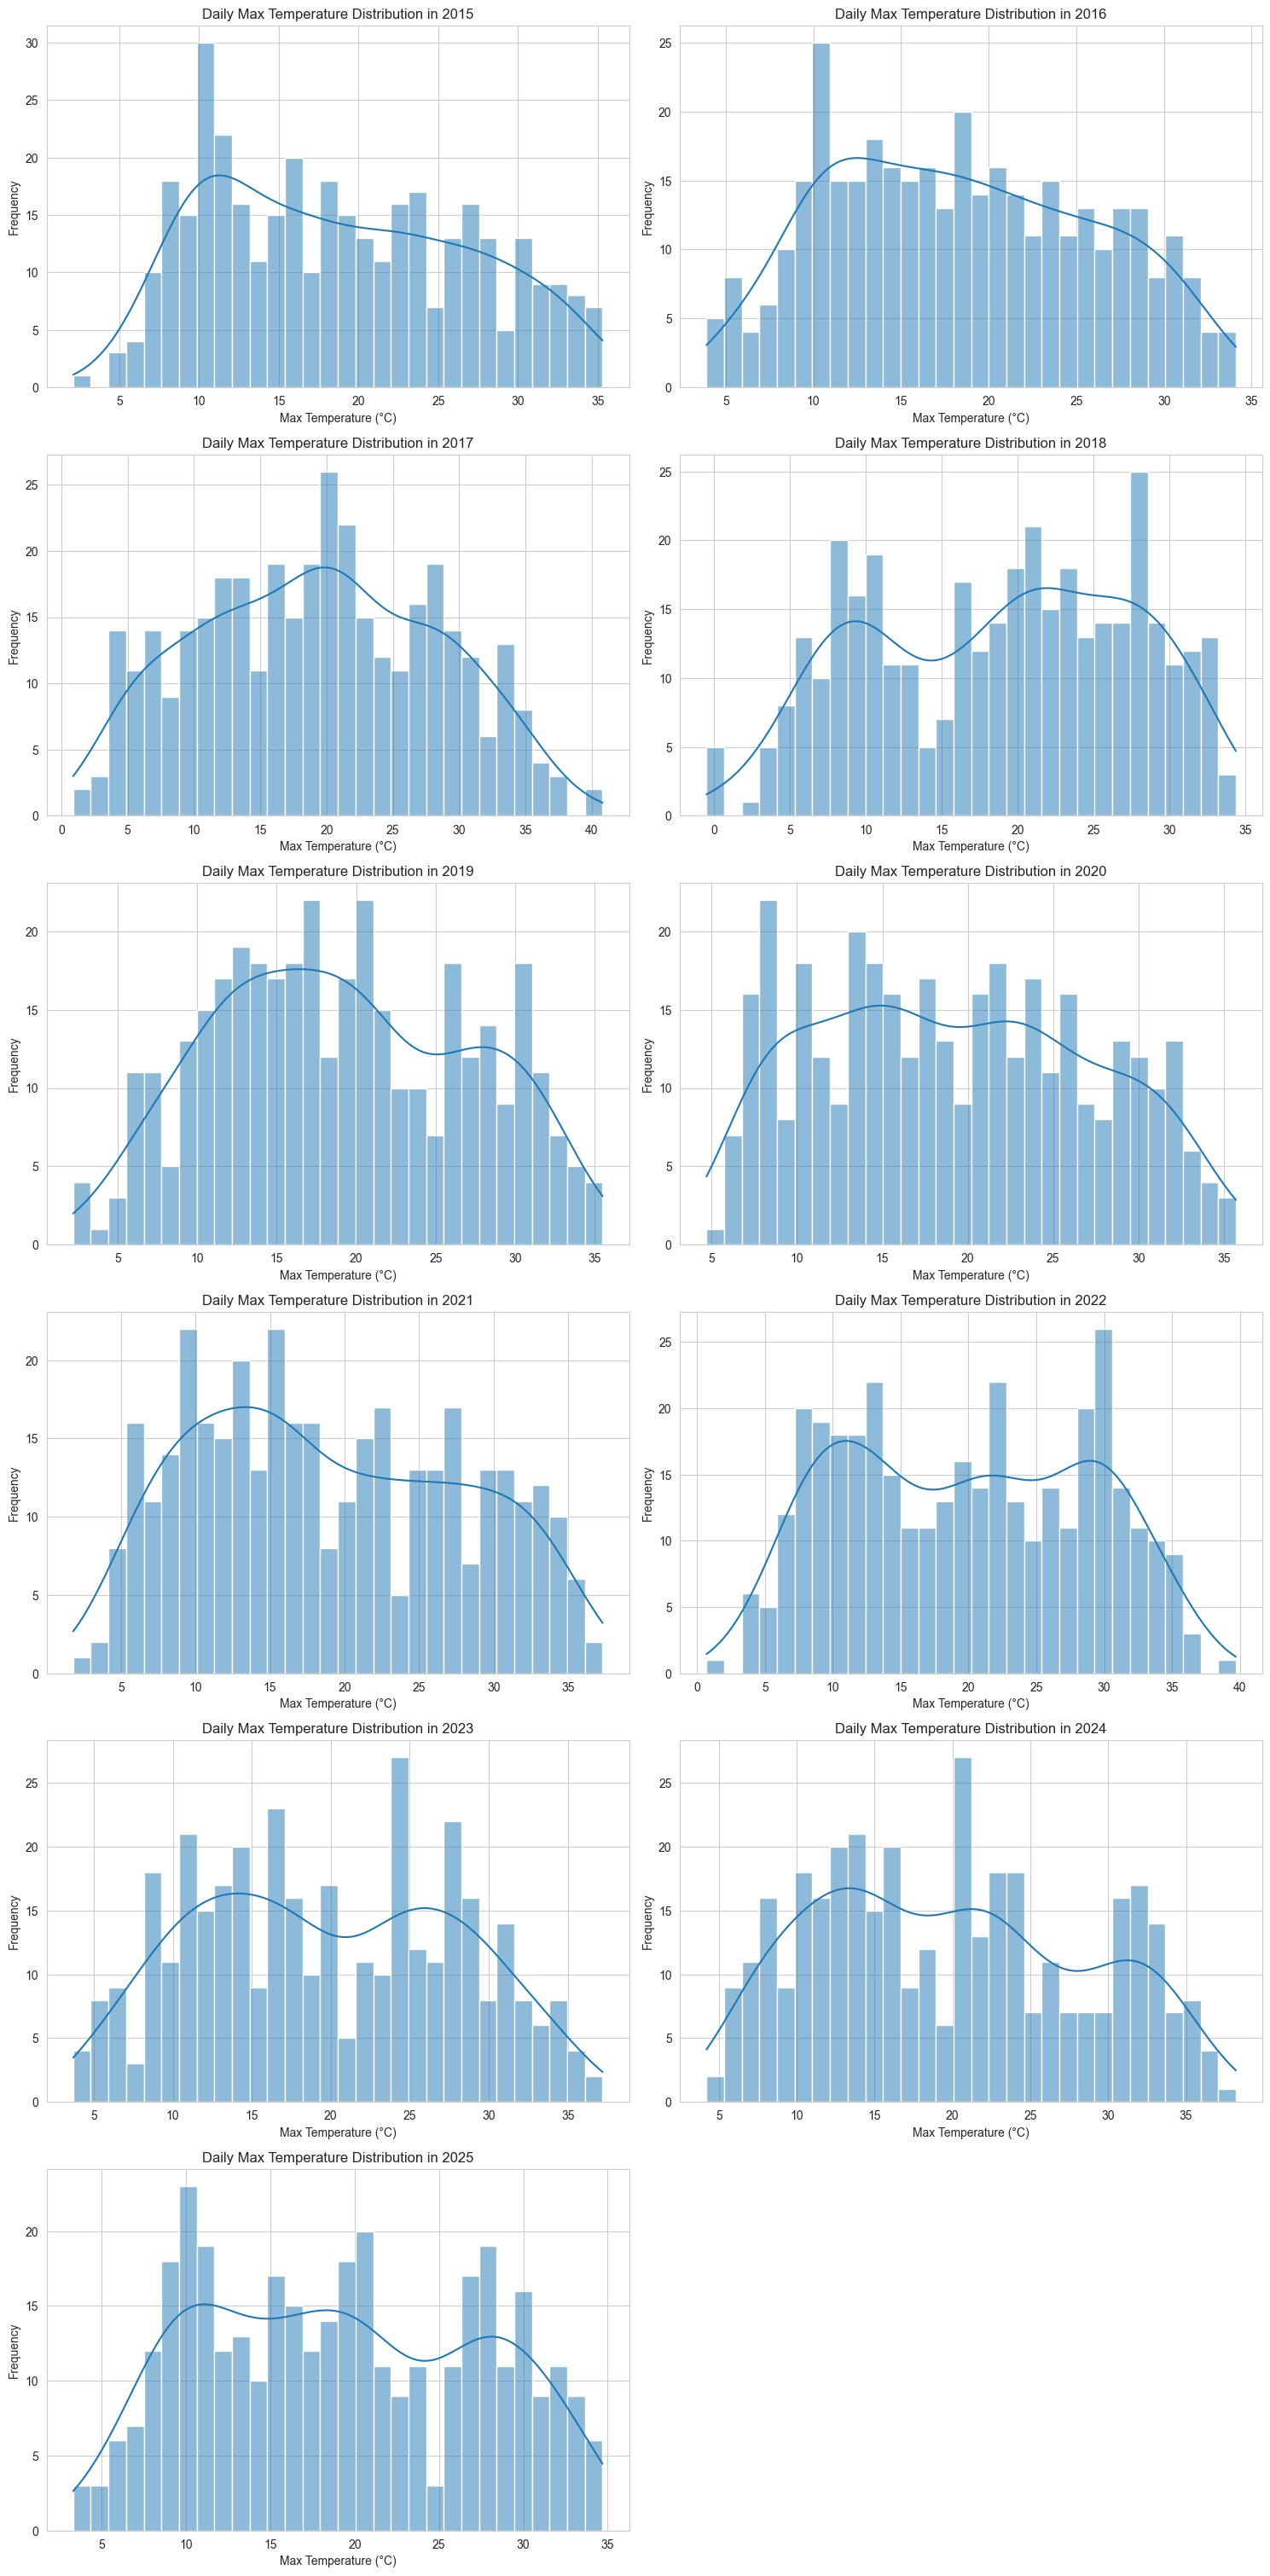

In [52]:
# Get unique years for iteration
years = df['year'].unique().tolist()
years.sort()

plt.figure(figsize=(15, 5 * len(years)))

for i, year in enumerate(years):
    plt.subplot(len(years), 2, i + 1)
    sns.histplot(df[df['year'] == year]['temp_max (°C)'], kde=True, bins=30)
    plt.title(f'Daily Max Temperature Distribution in {year}')
    plt.xlabel('Max Temperature (°C)')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Temperature by Season
**Seasonal analysis with boxplot and statistics**

In [53]:
df_monthly_avg = df.groupby(['year', 'month'])['temp_max (°C)'].mean().reset_index()
display(df_monthly_avg.head())

,year,month,temp_max (°C)
0,2015,1,9.493548
1,2015,2,8.946429
2,2015,3,12.841935
3,2015,4,17.423333
4,2015,5,21.932258


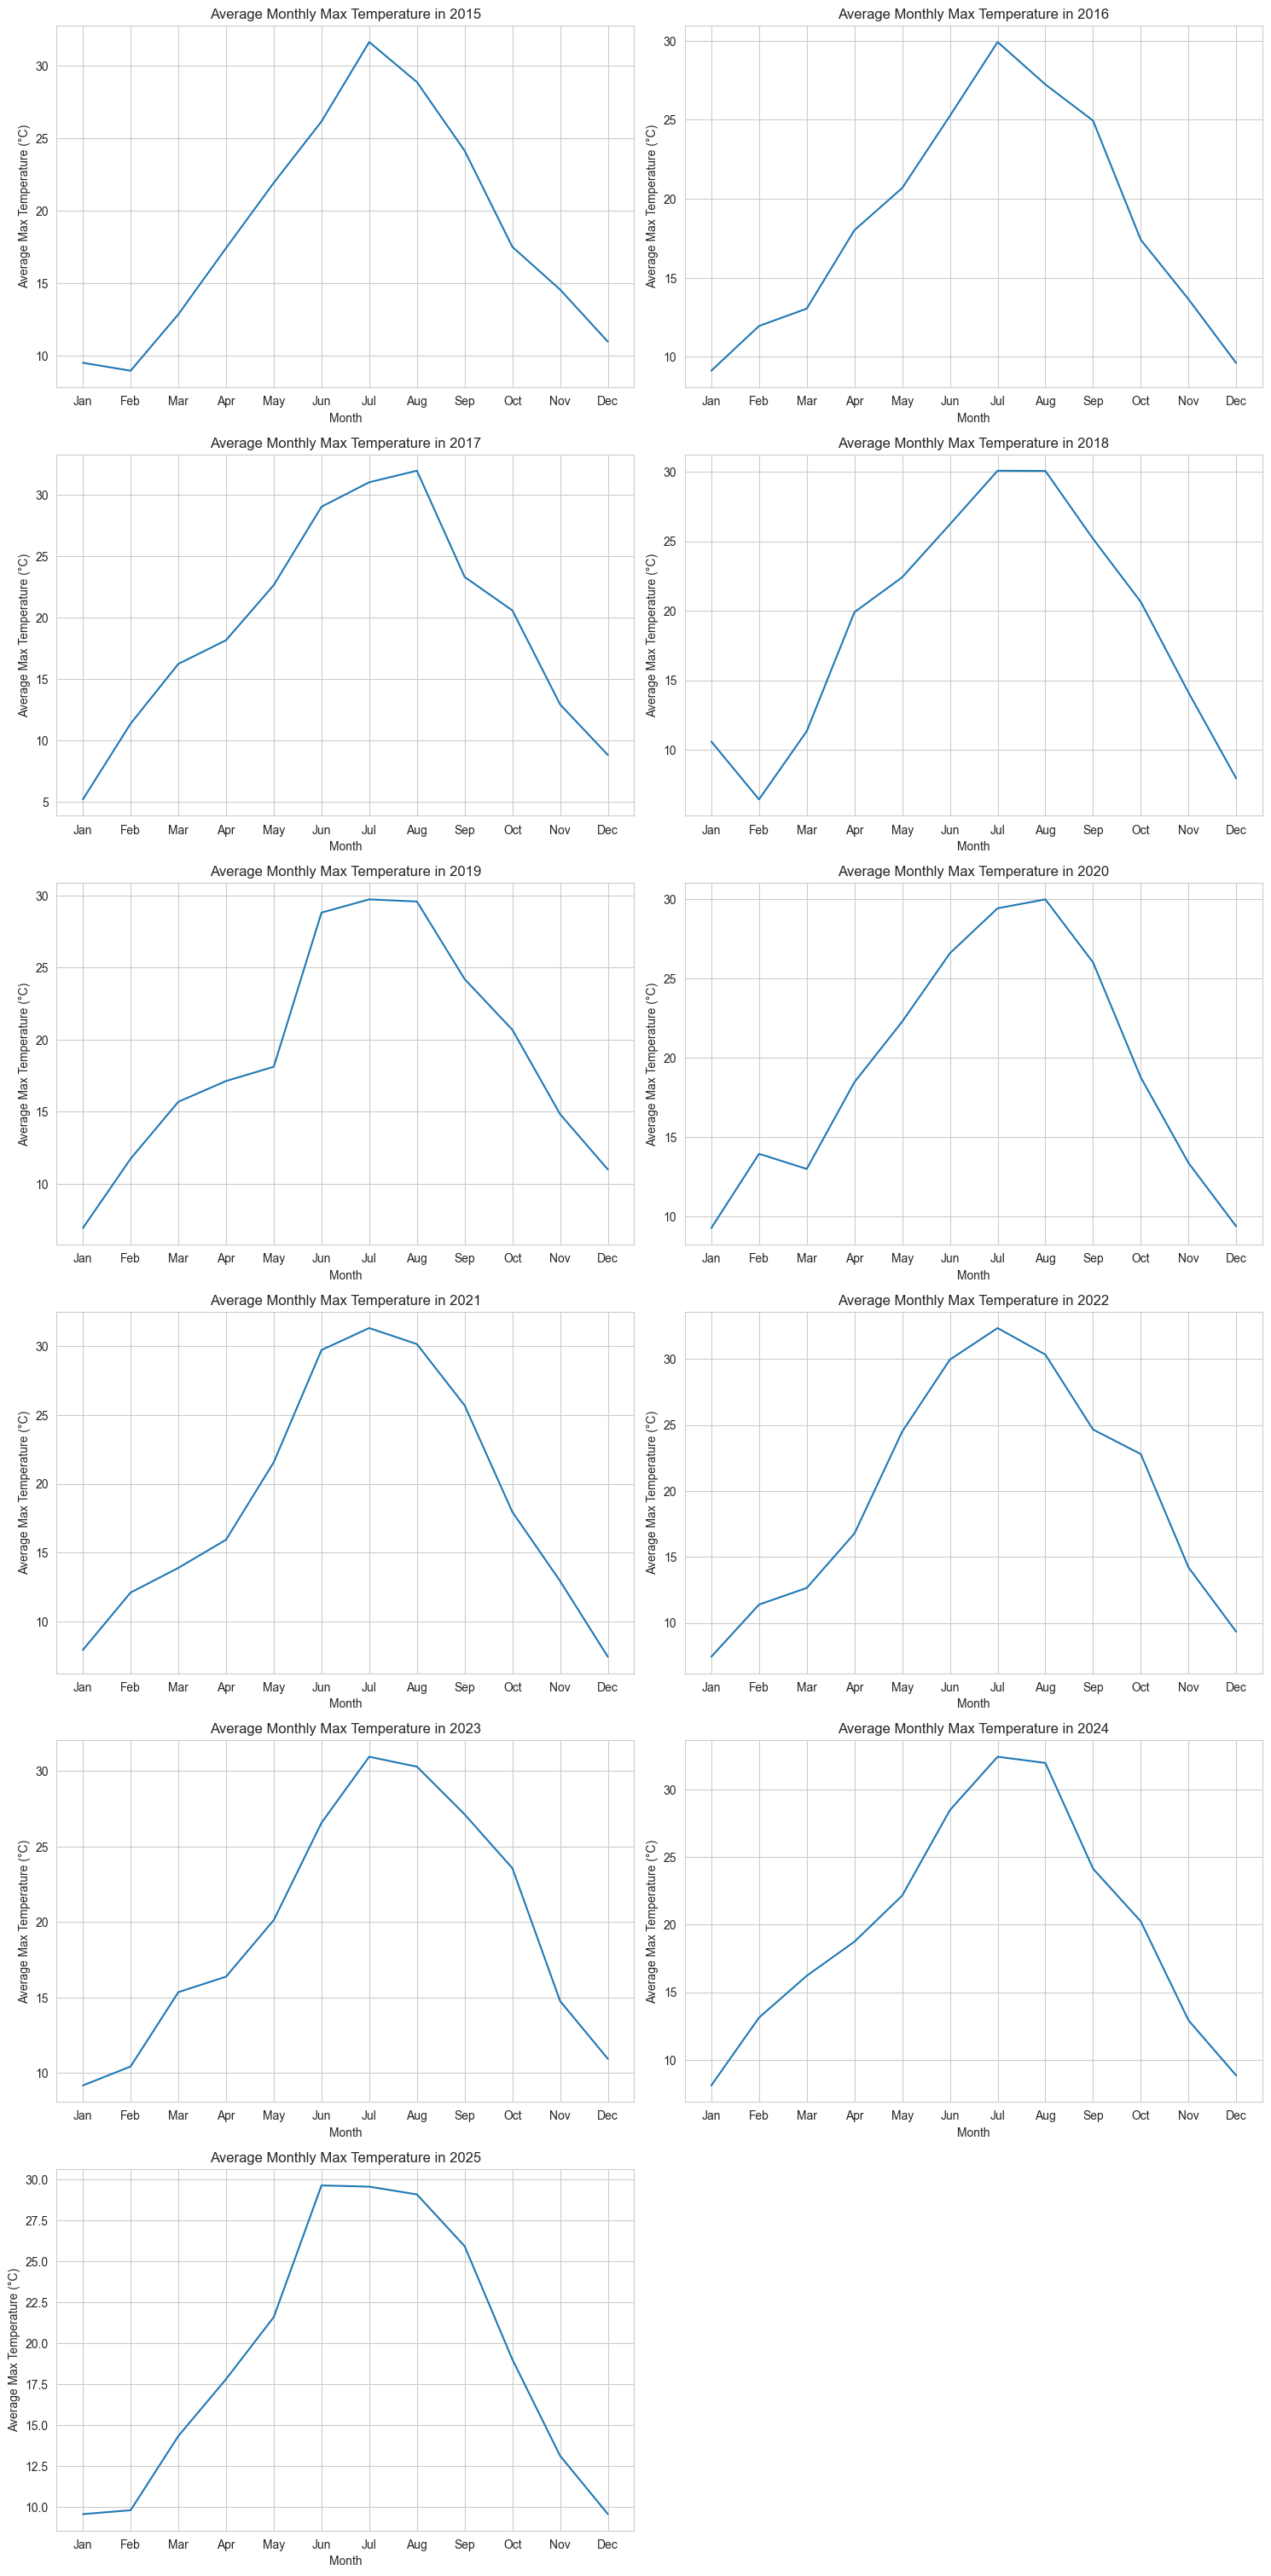

In [54]:
plt.figure(figsize=(15, 5 * len(years)))

for i, year in enumerate(years):
    plt.subplot(len(years), 2, i + 1)
    sns.lineplot(data=df_monthly_avg[df_monthly_avg['year'] == year], x='month', y='temp_max (°C)')
    plt.title(f'Average Monthly Max Temperature in {year}')
    plt.xlabel('Month')
    plt.ylabel('Average Max Temperature (°C)')
    plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    plt.grid(True)

plt.tight_layout()
plt.show()

C:\Users\elzem\AppData\Local\Temp\ipykernel_26380\259213109.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='season', y='temp_max (°C)',


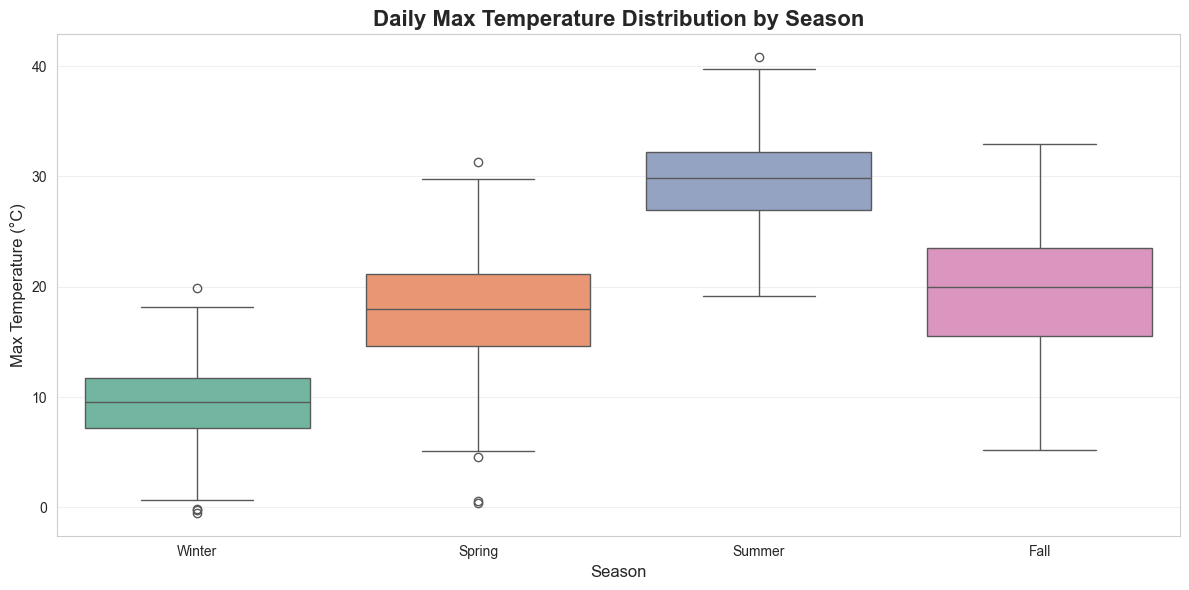

In [55]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='season', y='temp_max (°C)', 
            order=['Winter', 'Spring', 'Summer', 'Fall'],
            palette='Set2')
plt.title('Daily Max Temperature Distribution by Season', fontsize=16, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Max Temperature (°C)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [56]:
print('\nDaily Max Temperature Statistics by Season:')
print(df.groupby('season')['temp_max (°C)'].describe())


Daily Max Temperature Statistics by Season:
         count       mean       std   min   25%   50%   75%   max
season                                                           
Fall    1001.0  19.573526  5.713199   5.2  15.5  20.0  23.5  32.9
Spring  1012.0  17.796146  4.772680   0.4  14.6  18.0  21.2  31.3
Summer  1012.0  29.547628  3.597453  19.2  27.0  29.9  32.2  40.8
Winter   993.0   9.588721  3.261471  -0.5   7.2   9.6  11.7  19.9


We can observe there are some outliers.

### Correlation Matrix
**IMPORTANT! Analyzing feature correlations to decide which features to keep/remove**

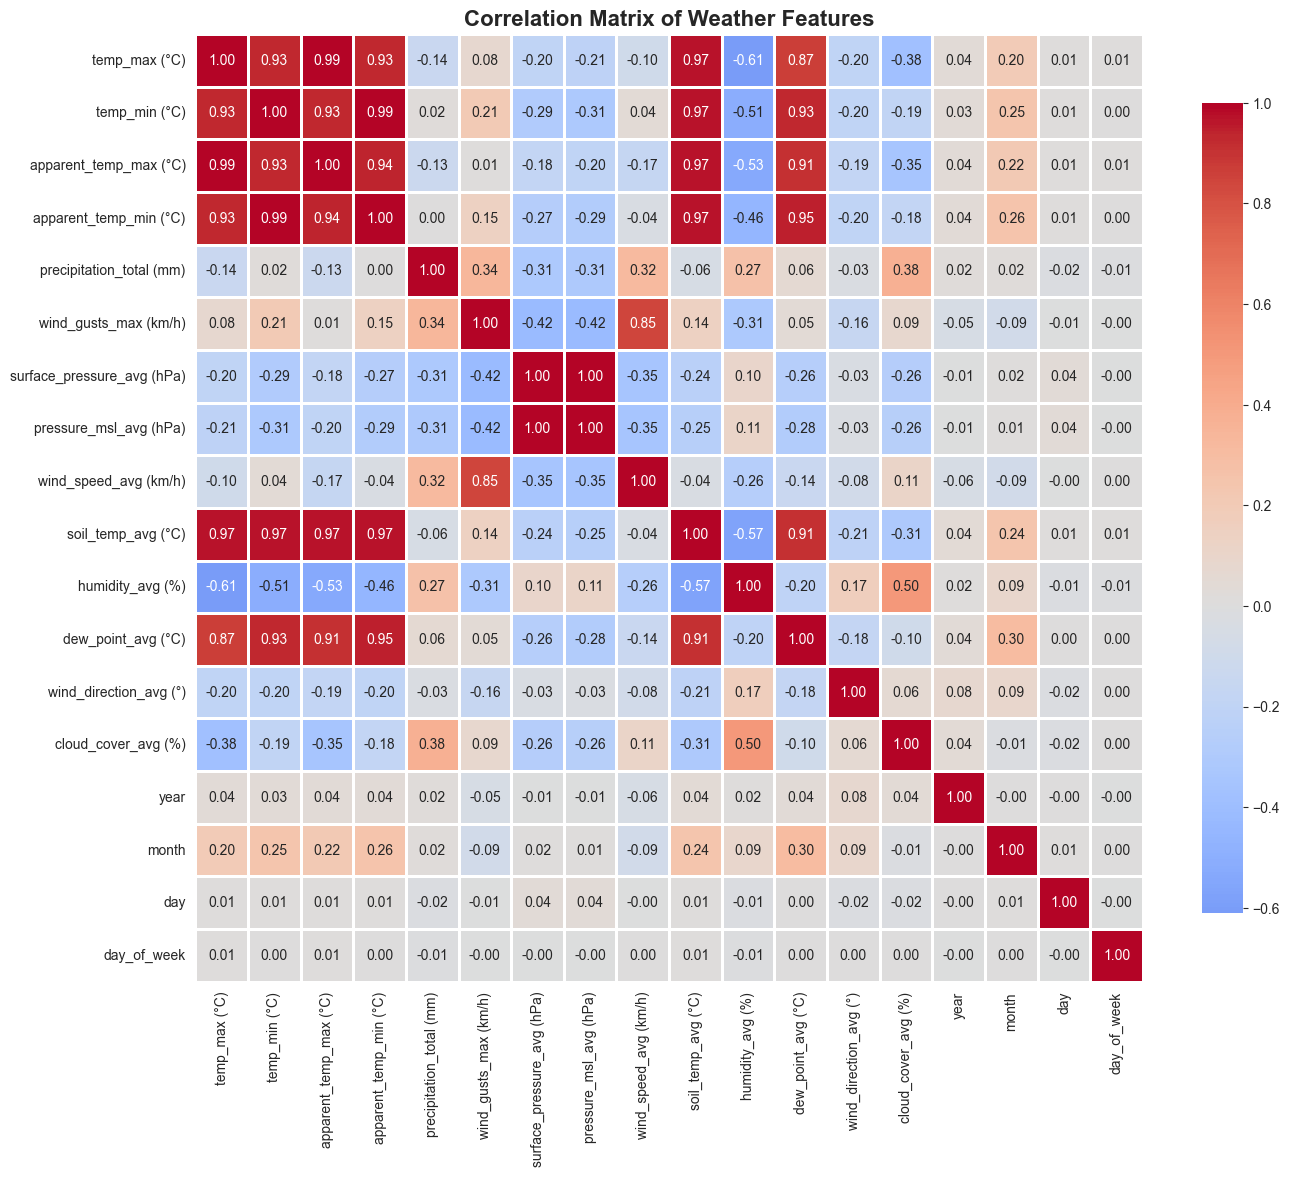

In [57]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numeric_cols].corr()

# Visualize correlation matrix
plt.figure(figsize=(14, 12))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Weather Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [58]:
# Show correlation with temperature specifically
print('CORRELATION WITH MAX TEMPERATURE (Target Variable)')
temp_corr = correlation['temp_max (°C)'].sort_values(ascending=False)
print(temp_corr)

CORRELATION WITH MAX TEMPERATURE (Target Variable)
temp_max (°C)                 1.000000
apparent_temp_max (°C)        0.991384
soil_temp_avg (°C)            0.972392
apparent_temp_min (°C)        0.928479
temp_min (°C)                 0.926654
dew_point_avg (°C)            0.871184
month                         0.199000
wind_gusts_max (km/h)         0.078407
year                          0.035468
day_of_week                   0.011040
day                           0.006863
wind_speed_avg (km/h)        -0.096553
precipitation_total (mm)     -0.143387
surface_pressure_avg (hPa)   -0.196815
wind_direction_avg (°)       -0.197436
pressure_msl_avg (hPa)       -0.214943
cloud_cover_avg (%)          -0.379700
humidity_avg (%)             -0.610229
Name: temp_max (°C), dtype: float64


In [59]:
print('HIGHLY CORRELATED FEATURE PAIRS (>0.9)')
high_corr_pairs = []
for i in range(len(correlation.columns)):
    for j in range(i+1, len(correlation.columns)):
        if abs(correlation.iloc[i, j]) > 0.9:
            high_corr_pairs.append((correlation.columns[i], correlation.columns[j], correlation.iloc[i, j]))

for pair in high_corr_pairs:
    print(f"{pair[0]} <-> {pair[1]}: {pair[2]:.3f}")

HIGHLY CORRELATED FEATURE PAIRS (>0.9)
temp_max (°C) <-> temp_min (°C): 0.927
temp_max (°C) <-> apparent_temp_max (°C): 0.991
temp_max (°C) <-> apparent_temp_min (°C): 0.928
temp_max (°C) <-> soil_temp_avg (°C): 0.972
temp_min (°C) <-> apparent_temp_max (°C): 0.929
temp_min (°C) <-> apparent_temp_min (°C): 0.993
temp_min (°C) <-> soil_temp_avg (°C): 0.973
temp_min (°C) <-> dew_point_avg (°C): 0.925
apparent_temp_max (°C) <-> apparent_temp_min (°C): 0.939
apparent_temp_max (°C) <-> soil_temp_avg (°C): 0.970
apparent_temp_max (°C) <-> dew_point_avg (°C): 0.907
apparent_temp_min (°C) <-> soil_temp_avg (°C): 0.972
apparent_temp_min (°C) <-> dew_point_avg (°C): 0.949
surface_pressure_avg (hPa) <-> pressure_msl_avg (hPa): 1.000
soil_temp_avg (°C) <-> dew_point_avg (°C): 0.907


### Feature Selection Decision
**Documenting which features to keep/remove based on correlation analysis**

**Feature Selection for Daily Aggregated Data:**

Features to REMOVE:
1. 'apparent_temp_max/min' - Derived from temperature (multicollinearity)
2. 'dew_point_avg' - Highly correlated with temperature
3. 'soil_temp_avg' - Very similar to air temperature
4. 'surface_pressure_avg' - Keep only pressure_msl (they're almost identical)
5. 'year', 'day' - Not useful for prediction (too specific)
6. 'hour' - No longer exists in daily aggregated data

Features to KEEP:
1. precipitation_total (mm) - Daily total rainfall
2. pressure_msl_avg (hPa) - Daily average sea-level pressure
3. wind_speed_avg (km/h) - Daily average wind speed
4. wind_direction_avg (°) - Daily average wind direction
5. wind_gusts_max (km/h) - Daily maximum wind gusts
6. humidity_avg (%) - Daily average relative humidity
7. cloud_cover_avg (%) - Daily average cloud cover
8. month - Seasonal patterns
9. day_of_week - Weekly patterns

In [60]:
# Define features to keep for modeling (updated for daily aggregated data)
features_to_keep = [
    'precipitation_total (mm)',
    'pressure_msl_avg (hPa)',
    'wind_speed_avg (km/h)',
    'wind_direction_avg (°)',
    'wind_gusts_max (km/h)',
    'humidity_avg (%)',
    'cloud_cover_avg (%)',
    'month',
    'day_of_week'
]

---
## Data Preparation
### Train-Test Split (Chronological)
**IMPORTANT! Splitting data chronologically (NOT random) for time series**

In [61]:
# Define features and target (using daily max temperature as target)
X = df[features_to_keep]
y = df['temp_max (°C)']

# Chronological split: 2015-2022 for training, 2023-2025 for testing (72% for training)
train_mask = df['year'] < 2023
test_mask = df['year'] >= 2023

X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print(f'Training set: {X_train.shape[0]} samples 2015-2022')
print(f'Testing set: {X_test.shape[0]} samples 2023-2025')
print(f'Number of features: {X_train.shape[1]}')

Training set: 2922 samples 2015-2022
Testing set: 1096 samples 2023-2025
Number of features: 9


### Feature Scaling
**Scaling features using StandardScaler (fit on training data only!)**
It is the same method as we learnt in the class: (X - X.mean()) / X.std()

In [62]:
# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

array([[-4.14062164e-01,  2.33782553e+00,  9.17414271e-01, ...,
        -5.69662160e-01, -1.60145110e+00, -5.13500882e-04],
       [-4.14062164e-01,  2.08255224e+00, -5.53077180e-01, ...,
        -8.02943508e-03, -1.60145110e+00,  4.99636359e-01],
       [-4.14062164e-01,  1.25127770e+00, -5.74492104e-01, ...,
         1.15478761e+00, -1.60145110e+00,  9.99786218e-01],
       ...,
       [-2.23606344e-01,  8.65095038e-01, -8.45747808e-01, ...,
         9.01657372e-01,  1.58815364e+00, -5.13500882e-04],
       [-4.14062164e-01,  6.45821832e-01, -9.24269196e-01, ...,
         1.28135274e+00,  1.58815364e+00,  4.99636359e-01],
       [-4.14062164e-01,  1.64400583e+00, -1.44536568e+00, ...,
         1.62149650e+00,  1.58815364e+00,  9.99786218e-01]],
      shape=(2922, 9))

---
## Model Training
### Linear Regression (Baseline)
**Training Linear Regression as baseline model**

In [63]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr_train = lr_model.predict(X_train_scaled)
y_pred_lr_test = lr_model.predict(X_test_scaled)

# Evaluate
lr_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_lr_train))
lr_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr_test))
lr_train_mae = mean_absolute_error(y_train, y_pred_lr_train)
lr_test_mae = mean_absolute_error(y_test, y_pred_lr_test)
lr_train_r2 = r2_score(y_train, y_pred_lr_train)
lr_test_r2 = r2_score(y_test, y_pred_lr_test)

print('LINEAR REGRESSION RESULTS')
print(f'Training RMSE: {lr_train_rmse:.3f}°C')
print(f'Testing RMSE: {lr_test_rmse:.3f}°C')
print(f'Training MAE: {lr_train_mae:.3f}°C')
print(f'Testing MAE: {lr_test_mae:.3f}°C')
print(f'Training R²: {lr_train_r2:.3f}')
print(f'Testing R²: {lr_test_r2:.3f}')

LINEAR REGRESSION RESULTS
Training RMSE: 5.294°C
Testing RMSE: 5.269°C
Training MAE: 4.182°C
Testing MAE: 4.303°C
Training R²: 0.601
Testing R²: 0.599


### Random Forest Regressor
**Training Random Forest model**

In [64]:
# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf_train = rf_model.predict(X_train_scaled)
y_pred_rf_test = rf_model.predict(X_test_scaled)

# Evaluate
rf_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
rf_train_mae = mean_absolute_error(y_train, y_pred_rf_train)
rf_test_mae = mean_absolute_error(y_test, y_pred_rf_test)
rf_train_r2 = r2_score(y_train, y_pred_rf_train)
rf_test_r2 = r2_score(y_test, y_pred_rf_test)

print('RANDOM FOREST RESULTS')
print(f'Training RMSE: {rf_train_rmse:.3f}°C')
print(f'Testing RMSE: {rf_test_rmse:.3f}°C')
print(f'Training MAE: {rf_train_mae:.3f}°C')
print(f'Testing MAE: {rf_test_mae:.3f}°C')
print(f'Training R²: {rf_train_r2:.3f}')
print(f'Testing R²: {rf_test_r2:.3f}')

RANDOM FOREST RESULTS
Training RMSE: 1.035°C
Testing RMSE: 2.906°C
Training MAE: 0.815°C
Testing MAE: 2.328°C
Training R²: 0.985
Testing R²: 0.878


### Support Vector Regression (SVR)
**Training SVR model**

In [65]:
# Train SVR
svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_svr_train = svr_model.predict(X_train_scaled)
y_pred_svr_test = svr_model.predict(X_test_scaled)

# Evaluate
svr_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_svr_train))
svr_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_svr_test))
svr_train_mae = mean_absolute_error(y_train, y_pred_svr_train)
svr_test_mae = mean_absolute_error(y_test, y_pred_svr_test)
svr_train_r2 = r2_score(y_train, y_pred_svr_train)
svr_test_r2 = r2_score(y_test, y_pred_svr_test)

print('SUPPORT VECTOR REGRESSION RESULTS')
print(f'Training RMSE: {svr_train_rmse:.3f}°C')
print(f'Testing RMSE: {svr_test_rmse:.3f}°C')
print(f'Training MAE: {svr_train_mae:.3f}°C')
print(f'Testing MAE: {svr_test_mae:.3f}°C')
print(f'Training R²: {svr_train_r2:.3f}')
print(f'Testing R²: {svr_test_r2:.3f}')

SUPPORT VECTOR REGRESSION RESULTS
Training RMSE: 2.195°C
Testing RMSE: 3.207°C
Training MAE: 1.455°C
Testing MAE: 2.510°C
Training R²: 0.931
Testing R²: 0.851


### MLP Regressor (Neural Network)
**Training Multi-layer Perceptron (Neural Network) model**

In [66]:
# Train MLP
mlp_model = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
mlp_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_mlp_train = mlp_model.predict(X_train_scaled)
y_pred_mlp_test = mlp_model.predict(X_test_scaled)

# Evaluate
mlp_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_mlp_train))
mlp_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlp_test))
mlp_train_mae = mean_absolute_error(y_train, y_pred_mlp_train)
mlp_test_mae = mean_absolute_error(y_test, y_pred_mlp_test)
mlp_train_r2 = r2_score(y_train, y_pred_mlp_train)
mlp_test_r2 = r2_score(y_test, y_pred_mlp_test)

print('MLP REGRESSOR (NEURAL NETWORK) RESULTS')
print(f'Training RMSE: {mlp_train_rmse:.3f}°C')
print(f'Testing RMSE: {mlp_test_rmse:.3f}°C')
print(f'Training MAE: {mlp_train_mae:.3f}°C')
print(f'Testing MAE: {mlp_test_mae:.3f}°C')
print(f'Training R²: {mlp_train_r2:.3f}')
print(f'Testing R²: {mlp_test_r2:.3f}')

MLP REGRESSOR (NEURAL NETWORK) RESULTS
Training RMSE: 2.414°C
Testing RMSE: 2.929°C
Training MAE: 1.917°C
Testing MAE: 2.343°C
Training R²: 0.917
Testing R²: 0.876


---
## Model Evaluation & Comparison
### Model Comparison Table
**Comparing all models side-by-side**

In [67]:
# Create comparison dataframe
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'SVR', 'MLP (Neural Network)'],
    'Train RMSE': [lr_train_rmse, rf_train_rmse, svr_train_rmse, mlp_train_rmse],
    'Test RMSE': [lr_test_rmse, rf_test_rmse, svr_test_rmse, mlp_test_rmse],
    'Train MAE': [lr_train_mae, rf_train_mae, svr_train_mae, mlp_train_mae],
    'Test MAE': [lr_test_mae, rf_test_mae, svr_test_mae, mlp_test_mae],
    'Train R²': [lr_train_r2, rf_train_r2, svr_train_r2, mlp_train_r2],
    'Test R²': [lr_test_r2, rf_test_r2, svr_test_r2, mlp_test_r2]
})

print('MODEL COMPARISON')
print(results.to_string(index=False))
print(f'Best Model (by Test RMSE): {results.loc[results["Test RMSE"].idxmin(), "Model"]}')
print(f'Best Test RMSE: {results["Test RMSE"].min():.3f}°C')

MODEL COMPARISON
               Model  Train RMSE  Test RMSE  Train MAE  Test MAE  Train R²  Test R²
   Linear Regression    5.294108   5.269165   4.182442  4.303384  0.601289 0.599116
       Random Forest    1.035175   2.906282   0.815360  2.327643  0.984756 0.878042
                 SVR    2.195188   3.207127   1.455201  2.509910  0.931449 0.851486
MLP (Neural Network)    2.413598   2.928520   1.917195  2.342956  0.917129 0.876168
Best Model (by Test RMSE): Random Forest
Best Test RMSE: 2.906°C


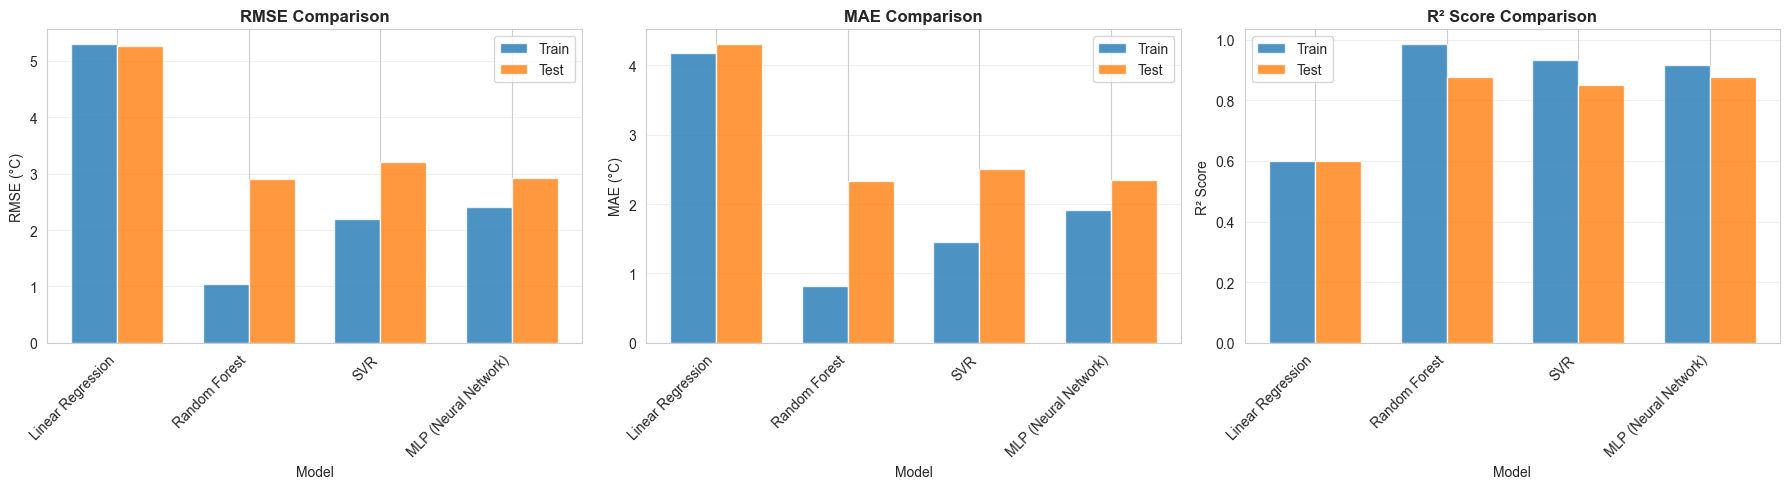

In [68]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RMSE comparison
x = np.arange(len(results))
width = 0.35
axes[0].bar(x - width/2, results['Train RMSE'], width, label='Train', alpha=0.8)
axes[0].bar(x + width/2, results['Test RMSE'], width, label='Test', alpha=0.8)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('RMSE (°C)')
axes[0].set_title('RMSE Comparison', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results['Model'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# MAE comparison
axes[1].bar(x - width/2, results['Train MAE'], width, label='Train', alpha=0.8)
axes[1].bar(x + width/2, results['Test MAE'], width, label='Test', alpha=0.8)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('MAE (°C)')
axes[1].set_title('MAE Comparison', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results['Model'], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# R² comparison
axes[2].bar(x - width/2, results['Train R²'], width, label='Train', alpha=0.8)
axes[2].bar(x + width/2, results['Test R²'], width, label='Test', alpha=0.8)
axes[2].set_xlabel('Model')
axes[2].set_ylabel('R² Score')
axes[2].set_title('R² Score Comparison', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(results['Model'], rotation=45, ha='right')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Feature Importance (Random Forest)
**Analyzing which features are most important for prediction**

In [69]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': features_to_keep,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('FEATURE IMPORTANCE (Random Forest)')
print(feature_importance.to_string(index=False))

FEATURE IMPORTANCE (Random Forest)
                 Feature  Importance
                   month    0.814370
        humidity_avg (%)    0.054859
  wind_direction_avg (°)    0.033550
precipitation_total (mm)    0.024071
   wind_speed_avg (km/h)    0.019978
  pressure_msl_avg (hPa)    0.017485
     cloud_cover_avg (%)    0.015026
   wind_gusts_max (km/h)    0.014090
             day_of_week    0.006571


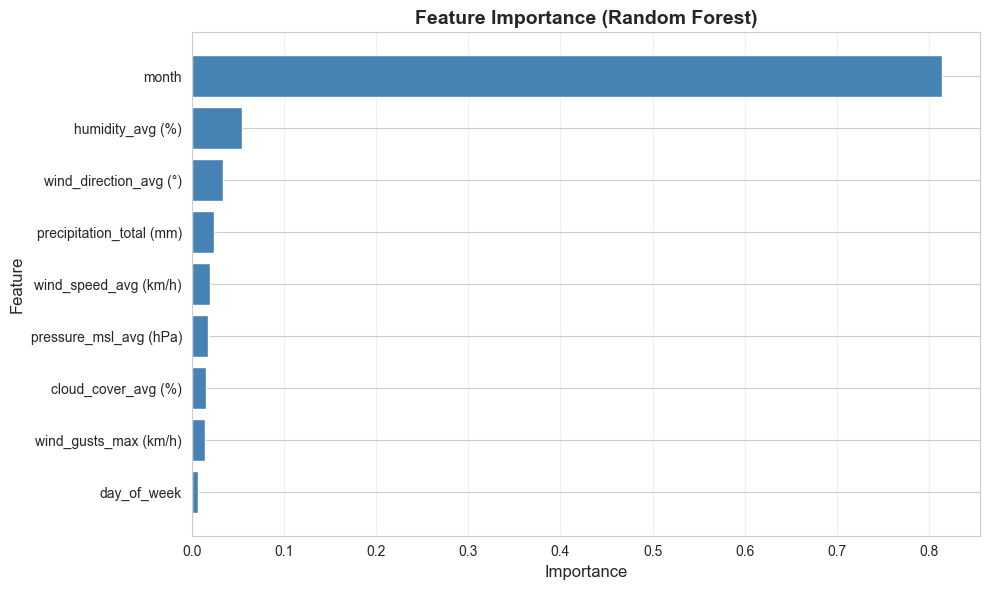

In [70]:
# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Actual vs Predicted (Best Model)
**Visualizing predictions vs actual values**

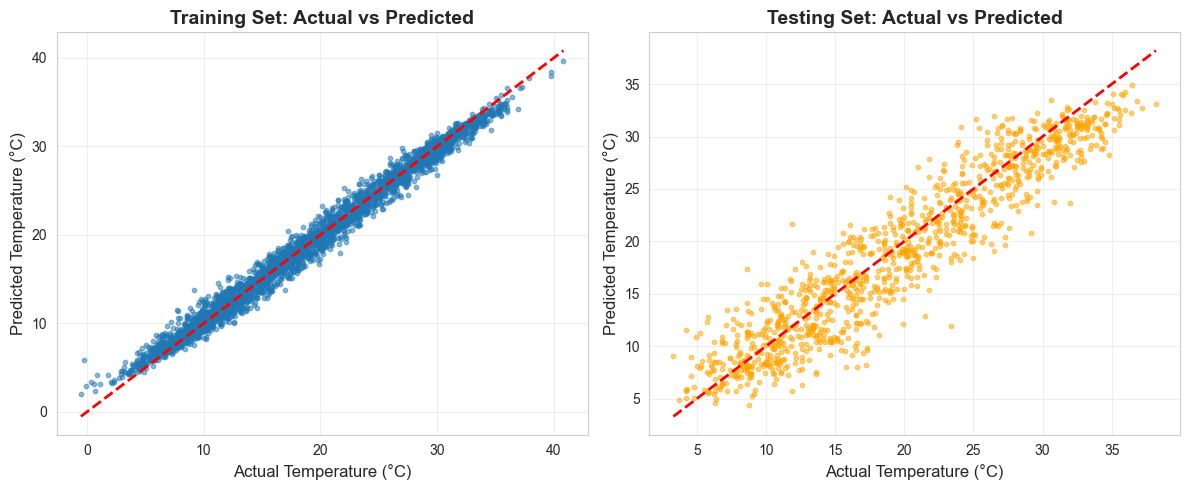

In [71]:
# Use Random Forest predictions (likely the best model)
plt.figure(figsize=(12, 5))

# Training set
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_rf_train, alpha=0.5, s=10)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature (°C)', fontsize=12)
plt.ylabel('Predicted Temperature (°C)', fontsize=12)
plt.title('Training Set: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Testing set
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_rf_test, alpha=0.5, s=10, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature (°C)', fontsize=12)
plt.ylabel('Predicted Temperature (°C)', fontsize=12)
plt.title('Testing Set: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## TIME HORIZON FORECASTING
### Create Lagged Target Variables
**Creating 3-day, 5-day, and 7-day ahead temperature targets**

In [72]:
# Create a copy for forecasting
df_forecast = df.copy()

# Sort by date to ensure correct order
df_forecast = df_forecast.sort_values('date').reset_index(drop=True)

# Data is now daily (1 observation per day), so:
# 3 days ahead = shift(-3)
# 5 days ahead = shift(-5)
# 7 days ahead = shift(-7)

# Create target variables for different horizons (predicting daily max temperature)
df_forecast['temp_3day_ahead'] = df_forecast['temp_max (°C)'].shift(-3)  # 3 days
df_forecast['temp_5day_ahead'] = df_forecast['temp_max (°C)'].shift(-5)  # 5 days
df_forecast['temp_7day_ahead'] = df_forecast['temp_max (°C)'].shift(-7)  # 7 days

# Remove rows with NaN (last 7 rows won't have 7-day ahead values)
df_forecast_clean = df_forecast.dropna()

print(f'\nOriginal dataset: {len(df)} rows')
print(f'Forecast dataset: {len(df_forecast_clean)} rows (removed last 7 rows with NaN)')


Original dataset: 4018 rows
Forecast dataset: 4011 rows (removed last 7 rows with NaN)


### Train Models for Each Horizon
**Training separate models for 3-day, 5-day, and 7-day forecasts**

In [73]:
# Prepare data for forecasting
X_forecast = df_forecast_clean[features_to_keep]

# Chronological split (same as before)
train_mask_forecast = df_forecast_clean['year'] < 2024
test_mask_forecast = df_forecast_clean['year'] >= 2024

X_train_forecast = X_forecast[train_mask_forecast]
X_test_forecast = X_forecast[test_mask_forecast]

# Scale features
scaler_forecast = StandardScaler()
X_train_forecast_scaled = scaler_forecast.fit_transform(X_train_forecast)
X_test_forecast_scaled = scaler_forecast.transform(X_test_forecast)


print(f'Training samples: {X_train_forecast.shape[0]}')
print(f'Testing samples: {X_test_forecast.shape[0]}')
print(f'Features: {X_train_forecast.shape[1]}')

Training samples: 3287
Testing samples: 724
Features: 9


In [74]:
# Dictionary to store results
results_by_horizon = {}

# Train models for each horizon
horizons = [
    ('3-day', 'temp_3day_ahead', 3),
    ('5-day', 'temp_5day_ahead', 5),
    ('7-day', 'temp_7day_ahead', 7)
]

for horizon_name, target_col, days in horizons:
    print(f'TRAINING FOR {horizon_name.upper()} HORIZON ({days} days ahead)')
    
    # Get target for this horizon
    y_train_h = df_forecast_clean.loc[train_mask_forecast, target_col]
    y_test_h = df_forecast_clean.loc[test_mask_forecast, target_col]
    
    # Train all 4 models
    models_h = {}
    
    # 1. Linear Regression
    lr_h = LinearRegression()
    lr_h.fit(X_train_forecast_scaled, y_train_h)
    models_h['Linear Regression'] = lr_h
    
    # 2. Random Forest
    rf_h = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_h.fit(X_train_forecast_scaled, y_train_h)
    models_h['Random Forest'] = rf_h
    
    # 3. SVR
    svr_h = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
    svr_h.fit(X_train_forecast_scaled, y_train_h)
    models_h['SVR'] = svr_h
    
    # 4. MLP
    mlp_h = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
    mlp_h.fit(X_train_forecast_scaled, y_train_h)
    models_h['MLP'] = mlp_h
    
    # Evaluate all models
    horizon_results = []
    for model_name, model in models_h.items():
        y_pred_train_h = model.predict(X_train_forecast_scaled)
        y_pred_test_h = model.predict(X_test_forecast_scaled)
        
        train_rmse_h = np.sqrt(mean_squared_error(y_train_h, y_pred_train_h))
        test_rmse_h = np.sqrt(mean_squared_error(y_test_h, y_pred_test_h))
        train_mae_h = mean_absolute_error(y_train_h, y_pred_train_h)
        test_mae_h = mean_absolute_error(y_test_h, y_pred_test_h)
        train_r2_h = r2_score(y_train_h, y_pred_train_h)
        test_r2_h = r2_score(y_test_h, y_pred_test_h)
        
        horizon_results.append({
            'Model': model_name,
            'Train RMSE': train_rmse_h,
            'Test RMSE': test_rmse_h,
            'Train MAE': train_mae_h,
            'Test MAE': test_mae_h,
            'Train R²': train_r2_h,
            'Test R²': test_r2_h
        })
    
    # Store results
    results_df_h = pd.DataFrame(horizon_results)
    results_by_horizon[horizon_name] = {
        'results': results_df_h,
        'models': models_h,
        'y_test': y_test_h,
        'X_test_scaled': X_test_forecast_scaled
    }
    
    # Print results
    print(f'\nResults for {horizon_name} horizon:')
    print(results_df_h.to_string(index=False))
    print(f'\nBest Model: {results_df_h.loc[results_df_h["Test RMSE"].idxmin(), "Model"]}')
    print(f'Best Test RMSE: {results_df_h["Test RMSE"].min():.3f}°C')


TRAINING FOR 3-DAY HORIZON (3 days ahead)

Results for 3-day horizon:
            Model  Train RMSE  Test RMSE  Train MAE  Test MAE  Train R²  Test R²
Linear Regression    5.943381   5.654326   4.750177  4.572912  0.495265 0.539073
    Random Forest    1.292654   3.359148   1.027965  2.727656  0.976124 0.837322
              SVR    2.875154   3.736219   1.972220  2.956114  0.881881 0.798750
              MLP    2.994772   3.341433   2.393622  2.684043  0.871848 0.839033

Best Model: MLP
Best Test RMSE: 3.341°C
TRAINING FOR 5-DAY HORIZON (5 days ahead)

Results for 5-day horizon:
            Model  Train RMSE  Test RMSE  Train MAE  Test MAE  Train R²  Test R²
Linear Regression    6.035758   5.876275   4.830537  4.718032  0.479298 0.504273
    Random Forest    1.300313   3.545354   1.037420  2.865519  0.975833 0.819550
              SVR    2.958375   3.876213   2.031485  3.084607  0.874907 0.784298
              MLP    3.166268   3.417169   2.536995  2.749055  0.856708 0.832363

Best Mod

### Compare Performance Across Horizons
**Comparing how accuracy changes with forecast horizon**


Horizon    Best Model  Test RMSE (°C)  Test MAE (°C)  Test R²
  3-day           MLP        3.341433       2.684043 0.839033
  5-day           MLP        3.417169       2.749055 0.832363
  7-day Random Forest        3.542003       2.860758 0.820807


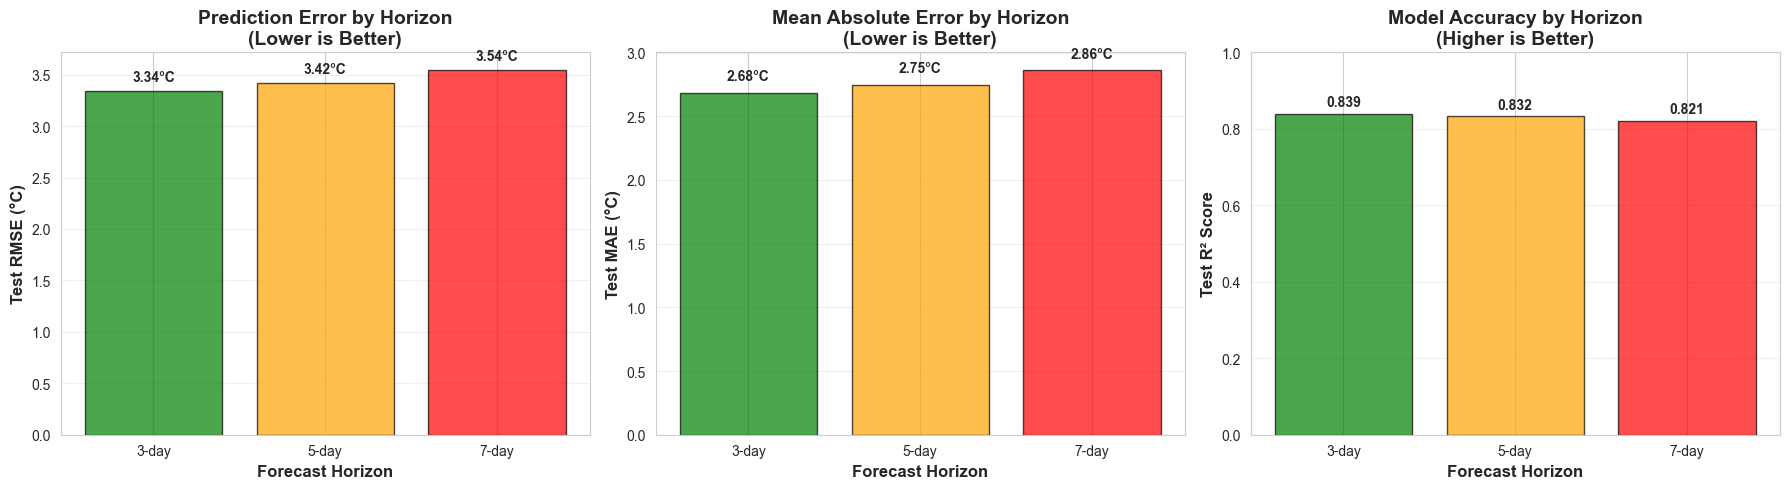

In [75]:
# Get best model for each horizon
comparison_data = []
for horizon_name in ['3-day', '5-day', '7-day']:
    results_df = results_by_horizon[horizon_name]['results']
    best_idx = results_df['Test RMSE'].idxmin()
    best_model = results_df.loc[best_idx, 'Model']
    best_rmse = results_df.loc[best_idx, 'Test RMSE']
    best_mae = results_df.loc[best_idx, 'Test MAE']
    best_r2 = results_df.loc[best_idx, 'Test R²']
    
    comparison_data.append({
        'Horizon': horizon_name,
        'Best Model': best_model,
        'Test RMSE (°C)': best_rmse,
        'Test MAE (°C)': best_mae,
        'Test R²': best_r2
    })

comparison_df = pd.DataFrame(comparison_data)
print('\n' + comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

horizons_list = ['3-day', '5-day', '7-day']
colors = ['green', 'orange', 'red']

# RMSE comparison
axes[0].bar(horizons_list, comparison_df['Test RMSE (°C)'], color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Test RMSE (°C)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Forecast Horizon', fontsize=12, fontweight='bold')
axes[0].set_title('Prediction Error by Horizon\n(Lower is Better)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison_df['Test RMSE (°C)']):
    axes[0].text(i, v + 0.1, f'{v:.2f}°C', ha='center', fontweight='bold')

# MAE comparison
axes[1].bar(horizons_list, comparison_df['Test MAE (°C)'], color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Test MAE (°C)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Forecast Horizon', fontsize=12, fontweight='bold')
axes[1].set_title('Mean Absolute Error by Horizon\n(Lower is Better)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison_df['Test MAE (°C)']):
    axes[1].text(i, v + 0.1, f'{v:.2f}°C', ha='center', fontweight='bold')

# R² comparison
axes[2].bar(horizons_list, comparison_df['Test R²'], color=colors, alpha=0.7, edgecolor='black')
axes[2].set_ylabel('Test R² Score', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Forecast Horizon', fontsize=12, fontweight='bold')
axes[2].set_title('Model Accuracy by Horizon\n(Higher is Better)', fontsize=14, fontweight='bold')
axes[2].set_ylim([0, 1])
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison_df['Test R²']):
    axes[2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [76]:
print('\n PART 1: SAME-TIME PREDICTION RESULTS')
print(f'Dataset: {df.shape[0]} samples, {len(features_to_keep)} features')
print(f'Training samples: {X_train.shape[0]} (2022-2023)')
print(f'Testing samples: {X_test.shape[0]} (2024-2025)')
print(f'\nBest Model: {results.loc[results["Test RMSE"].idxmin(), "Model"]}')
print(f'Best Test RMSE: {results["Test RMSE"].min():.3f}°C')
print(f'Best Test R²: {results.loc[results["Test RMSE"].idxmin(), "Test R²"]:.3f}')
print('\nPART 2: HORIZON FORECASTING RESULTS')

for horizon_name in ['3-day', '5-day', '7-day']:
    results_df = results_by_horizon[horizon_name]['results']
    best_idx = results_df['Test RMSE'].idxmin()
    best_model = results_df.loc[best_idx, 'Model']
    best_rmse = results_df.loc[best_idx, 'Test RMSE']
    best_r2 = results_df.loc[best_idx, 'Test R²']
    print(f'{horizon_name} forecast: {best_model} - RMSE: {best_rmse:.3f}°C, R²: {best_r2:.3f}')


 PART 1: SAME-TIME PREDICTION RESULTS
Dataset: 4018 samples, 9 features
Training samples: 2922 (2022-2023)
Testing samples: 1096 (2024-2025)

Best Model: Random Forest
Best Test RMSE: 2.906°C
Best Test R²: 0.878

PART 2: HORIZON FORECASTING RESULTS
3-day forecast: MLP - RMSE: 3.341°C, R²: 0.839
5-day forecast: MLP - RMSE: 3.417°C, R²: 0.832
7-day forecast: Random Forest - RMSE: 3.542°C, R²: 0.821


missing stuff:
hyperparameter optimization
